In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## Load data

In [2]:
AGENT_ROOT = PROJECT_ROOT / "datasets" / "experiments" / "agent"

# Always pick the latest file in each folder
def latest(folder, pattern):
    files = sorted(folder.glob(pattern))
    assert files, f"No files matching {pattern} in {folder}"
    print(f"  {pattern}: {files[-1].name}")
    return files[-1]

print("Loading:")
div  = pd.read_csv(latest(AGENT_ROOT / "tasks/division",   "division_*.csv"))
ext  = pd.read_csv(latest(AGENT_ROOT / "tasks/extraction", "extraction_*.csv"),
                   usecols=["index","document","chunk_idx","type","relevance_score",
                            "input_tokens","output_tokens","latency_ms"])
meta = pd.read_csv(latest(AGENT_ROOT / "tasks/meta",       "meta_*.csv"))
qa   = pd.read_csv(latest(AGENT_ROOT / "results",          "qa_results_*.csv"))

# Normalise judge score (0-10) to [0, 1]
qa["score"] = qa["judge_score"] / 10.0

# Map company → index group
INDEX_MAP = {
    "Axa": "CAC40", "BNP Paribas": "CAC40", "LVMH": "CAC40", "Orange": "CAC40",
    "Sanofi": "CAC40", "Engie": "CAC40", "Suez": "CAC40",
    "Total Energies S.A": "CAC40", "Veolia Environment S.A": "CAC40",
    "BASF": "DAX", "Siemens AG": "DAX",
    "Ali Baba Group": "Other", "ArcelorMittal SA": "Other", "BP": "Other",
    "Baoshan Iron & Steel": "Other", "Hindustan Unilever": "Other",
    "NTPC": "Other", "Nestle": "Other", "Roche Holding AG": "Other",
    "SPD Bank": "Other", "Samsung": "Other", "Sinopharm": "Other",
    "Bank of America": "SP500", "AT&T": "SP500", "Apple": "SP500",
    "ExxonMobil": "SP500", "General Electric": "SP500", "Google": "SP500",
    "Meta": "SP500", "Microsoft": "SP500", "NVIDIA": "SP500",
    "Pfizer": "SP500", "Sysco": "SP500",
}
qa["index"] = qa["company"].map(INDEX_MAP).fillna("Other")

print(f"\nQA rows: {len(qa):,}  |  Extraction chunks: {len(ext):,}  |  PDFs: {len(meta):,}")

Loading:
  division_*.csv: division_20260624_143048.csv
  extraction_*.csv: extraction_20260624_143048.csv
  meta_*.csv: meta_20260624_143048.csv
  qa_results_*.csv: qa_results_20260625_230315.csv

QA rows: 6,270  |  Extraction chunks: 218  |  PDFs: 32


---
## Extraction Pipeline
How the agent divides and extracts content from ESG PDFs.

#### Plot 1 — Chunk type distribution & relevance scores
Left: how many chunks of each type were extracted across all documents.
Right: relevance score assigned by the extraction agent per chunk type.

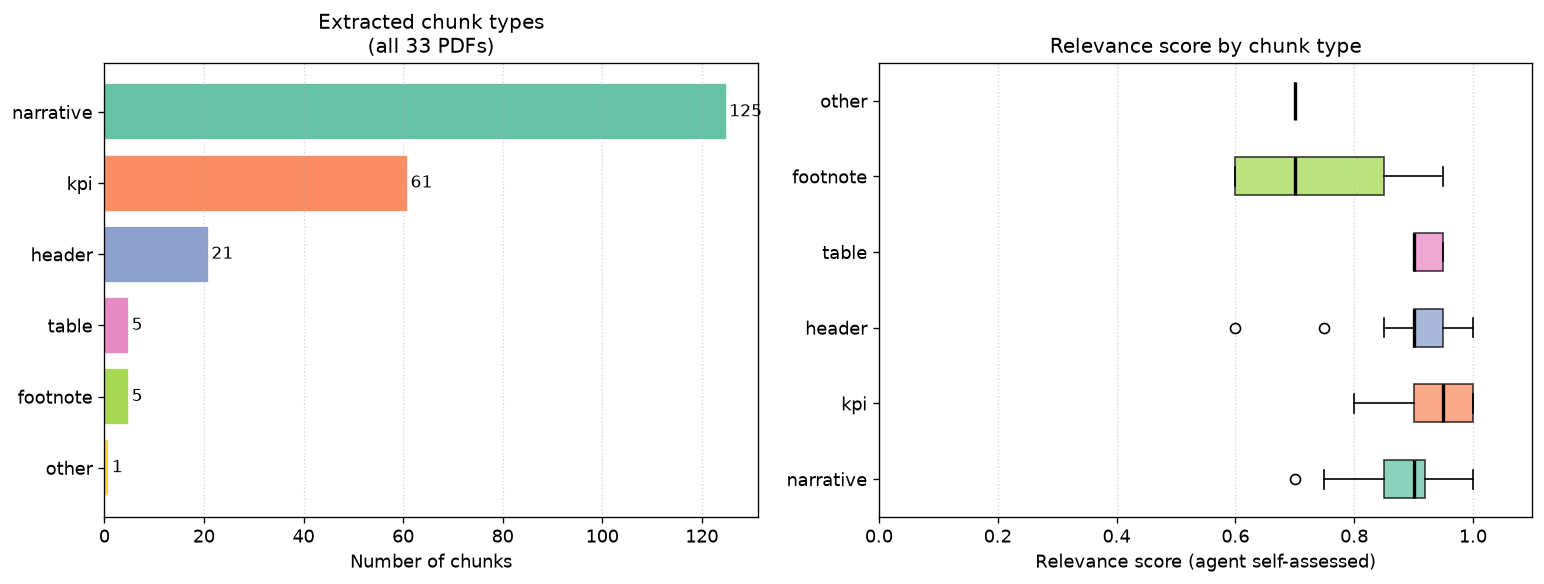

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: chunk type counts
type_counts = ext["type"].value_counts()
colors_bar  = plt.cm.Set2.colors
axes[0].barh(type_counts.index, type_counts.values,
             color=colors_bar[:len(type_counts)], edgecolor="white")
axes[0].set_xlabel("Number of chunks", fontsize=11)
axes[0].set_title("Extracted chunk types\n(all 33 PDFs)", fontsize=12)
axes[0].invert_yaxis()
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 0.5, i, str(v), va="center", fontsize=10)
axes[0].grid(axis="x", linestyle=":", alpha=0.5)

# Right: relevance score box per type
order = type_counts.index.tolist()
data  = [ext[ext["type"] == t]["relevance_score"].dropna().values for t in order]
bp = axes[1].boxplot(data, vert=False, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
axes[1].set_yticklabels(order)
for patch, color in zip(bp["boxes"], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_xlabel("Relevance score (agent self-assessed)", fontsize=11)
axes[1].set_title("Relevance score by chunk type", fontsize=12)
axes[1].set_xlim(0, 1.1)
axes[1].grid(axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

#### Plot 2 — Document size vs pipeline cost
Left: total pages per document vs division latency — does a longer doc take longer to divide?
Right: number of chunks extracted per document, coloured by index group.

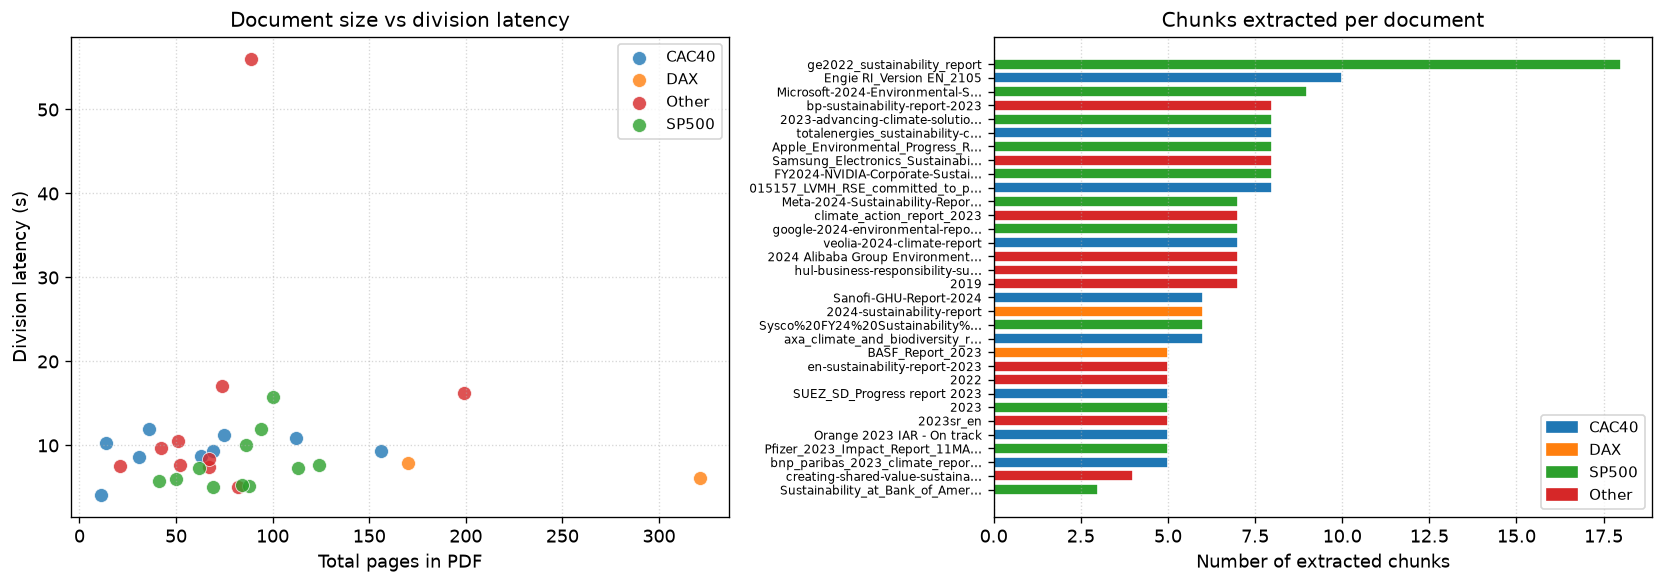

In [4]:
index_colors = {"CAC40": "#1f77b4", "DAX": "#ff7f0e", "SP500": "#2ca02c", "Other": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: pages vs division latency scatter
for idx, grp in meta.groupby("index"):
    axes[0].scatter(grp["total_pages"], grp["division_latency_ms"] / 1000,
                    label=idx, color=index_colors.get(idx, "grey"),
                    s=70, alpha=0.8, edgecolors="white", linewidth=0.5)
axes[0].set_xlabel("Total pages in PDF", fontsize=11)
axes[0].set_ylabel("Division latency (s)", fontsize=11)
axes[0].set_title("Document size vs division latency", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(linestyle=":", alpha=0.5)

# Right: extractions per document (horizontal bar, sorted)
meta_sorted = meta.sort_values("num_extractions", ascending=True)
bar_colors  = [index_colors.get(i, "grey") for i in meta_sorted["index"]]
short_names = [d[:30] + "…" if len(d) > 30 else d for d in meta_sorted["document"]]
axes[1].barh(range(len(meta_sorted)), meta_sorted["num_extractions"],
             color=bar_colors, edgecolor="white")
axes[1].set_yticks(range(len(meta_sorted)))
axes[1].set_yticklabels(short_names, fontsize=7)
axes[1].set_xlabel("Number of extracted chunks", fontsize=11)
axes[1].set_title("Chunks extracted per document", fontsize=12)
axes[1].grid(axis="x", linestyle=":", alpha=0.5)
patches = [mpatches.Patch(color=c, label=l) for l, c in index_colors.items()]
axes[1].legend(handles=patches, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

---
## Agent QA Performance
The agent pipeline (supervisor + 3 sub-agents) is evaluated on the full CFB dataset
(6 270 rows, 3 perturbation levels). Judge score normalised from 0–10 to 0–1.

#### Plot 3 — Score by question type & perturbation level
Left: mean score per question type (NR / LR / PE).
Right: how each question type degrades across perturbation levels 0→3.

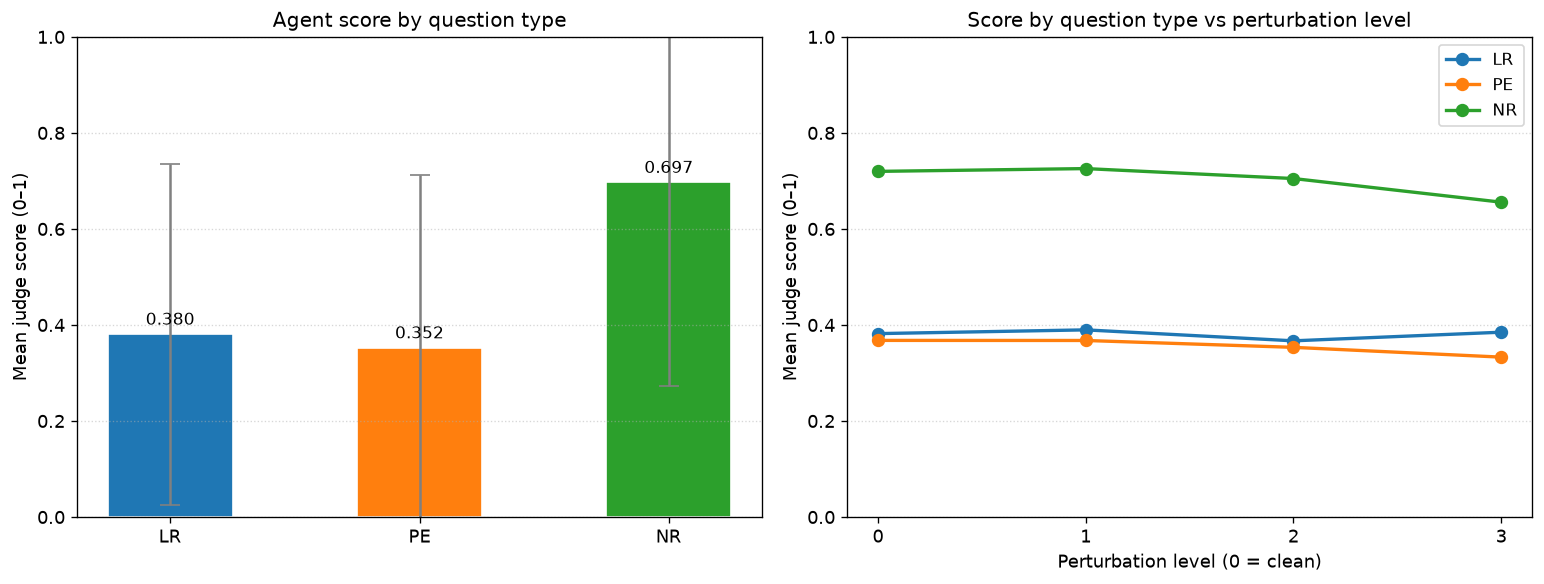

In [5]:
type_colors = {"LR": "#1f77b4", "PE": "#ff7f0e", "NR": "#2ca02c"}
levels = [0, 1, 2, 3]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart by question type
means = {qt: qa[qa["question_type"] == qt]["score"].mean() for qt in ["LR", "PE", "NR"]}
stds  = {qt: qa[qa["question_type"] == qt]["score"].std()  for qt in ["LR", "PE", "NR"]}
axes[0].bar(means.keys(), means.values(),
            color=[type_colors[k] for k in means],
            yerr=stds.values(), capsize=6, edgecolor="white", width=0.5,
            error_kw={"elinewidth": 1.5, "ecolor": "grey"})
axes[0].set_ylabel("Mean judge score (0–1)", fontsize=11)
axes[0].set_title("Agent score by question type", fontsize=12)
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)
for qt, mean in means.items():
    axes[0].text(list(means.keys()).index(qt), mean + 0.02, f"{mean:.3f}",
                 ha="center", fontsize=10)

# Right: line per question type across perturbation levels
for qt, color in type_colors.items():
    ys = [qa[(qa["question_type"] == qt) & (qa["perturbation_level"] == lvl)]["score"].mean()
          for lvl in levels]
    axes[1].plot(levels, ys, "o-", color=color, linewidth=2, markersize=7, label=qt)
axes[1].set_xlabel("Perturbation level (0 = clean)", fontsize=11)
axes[1].set_ylabel("Mean judge score (0–1)", fontsize=11)
axes[1].set_title("Score by question type vs perturbation level", fontsize=12)
axes[1].set_xticks(levels)
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

#### Plot 4 — Perturbation type impact & tool usage
Left: mean score drop at perturbation level 3 per perturbation type (vs clean baseline).
Right: how often each tool was called by the agent across all queries.

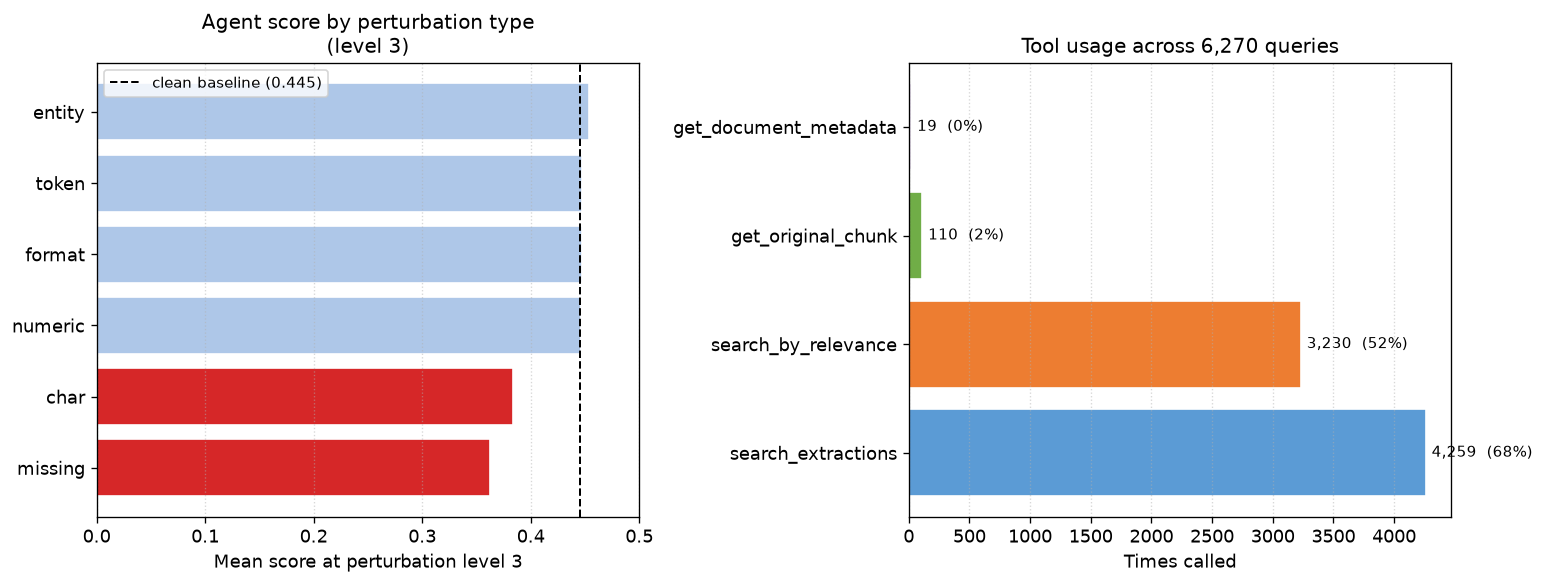

In [6]:
import json as _json
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: score at level 3 by perturbation type
baseline  = qa[qa["perturbation_level"] == 0]["score"].mean()
ptypes    = [pt for pt in qa["perturbation_type"].unique() if pt != "none"]
pt_means  = {pt: qa[(qa["perturbation_type"] == pt) & (qa["perturbation_level"] == 3)]["score"].mean()
             for pt in ptypes}
pt_sorted = sorted(pt_means.items(), key=lambda x: x[1])
bar_colors = ["#d62728" if v < baseline else "#aec7e8" for _, v in pt_sorted]

axes[0].barh([p for p, _ in pt_sorted], [float(v) for _, v in pt_sorted],
             color=bar_colors, edgecolor="white")
axes[0].axvline(baseline, color="black", linewidth=1.2, linestyle="--",
                label=f"clean baseline ({baseline:.3f})")
axes[0].set_xlabel("Mean score at perturbation level 3", fontsize=11)
axes[0].set_title("Agent score by perturbation type\n(level 3)", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 0.5)
axes[0].grid(axis="x", linestyle=":", alpha=0.5)

# Right: tool usage — filter None (JSON null) before counting
tools_flat = []
for t in qa["tools_used"].dropna():
    try:
        tools_flat.extend(x for x in _json.loads(t) if x is not None)
    except:
        pass
tool_counts = Counter(tools_flat)
tool_names  = list(tool_counts.keys())
tool_vals   = [int(tool_counts[k]) for k in tool_names]
palette     = ["#5b9bd5", "#ed7d31", "#70ad47", "#9467bd", "#8c564b"]
t_colors    = [palette[i % len(palette)] for i in range(len(tool_names))]

axes[1].barh(tool_names, tool_vals, color=t_colors, edgecolor="white")
axes[1].set_xlabel("Times called", fontsize=11)
axes[1].set_title(f"Tool usage across {len(qa):,} queries", fontsize=12)
axes[1].grid(axis="x", linestyle=":", alpha=0.5)
for i, (tool, count) in enumerate(zip(tool_names, tool_vals)):
    axes[1].text(count + 50, i, f"{count:,}  ({count/len(qa)*100:.0f}%)",
                 va="center", fontsize=9)

plt.tight_layout()
plt.show()

#### Plot 5 — Supervisor confidence & score by company group
Left: distribution of supervisor confidence values (0 = not confident, 1 = confident).
Right: mean agent score per company index group (CAC40 / DAX / SP500 / Other).

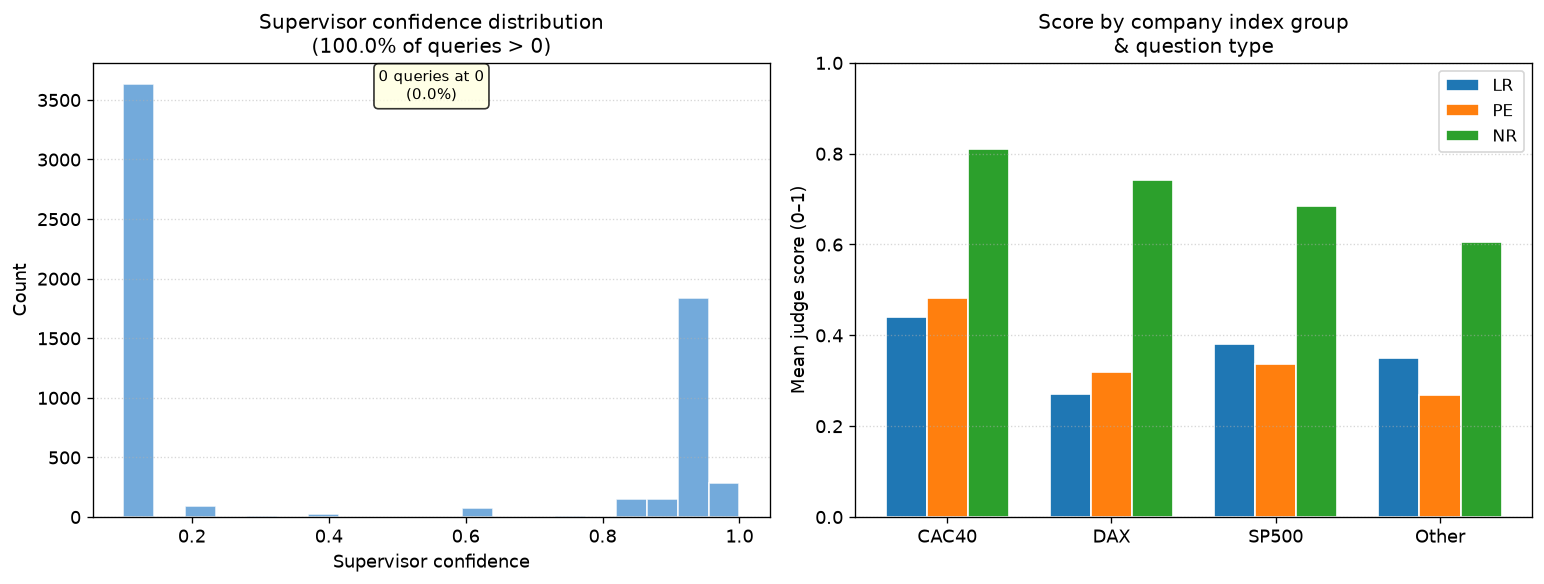

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: supervisor confidence histogram
conf = qa["supervisor_confidence"]
axes[0].hist(conf[conf > 0], bins=20, color="#5b9bd5", edgecolor="white", alpha=0.85)
pct_confident = (conf > 0).mean() * 100
axes[0].set_xlabel("Supervisor confidence", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title(f"Supervisor confidence distribution\n"
                  f"({pct_confident:.1f}% of queries > 0)", fontsize=12)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)
zero_count = (conf == 0).sum()
axes[0].text(0.5, 0.92, f"{zero_count:,} queries at 0\n({100-pct_confident:.1f}%)",
             transform=axes[0].transAxes, ha="center", fontsize=9,
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

# Right: score by index group, split by question type
idx_order  = ["CAC40", "DAX", "SP500", "Other"]
x          = np.arange(len(idx_order))
width      = 0.25
for i, (qt, color) in enumerate(type_colors.items()):
    means = [qa[(qa["index"] == idx) & (qa["question_type"] == qt)]["score"].mean()
             for idx in idx_order]
    axes[1].bar(x + i * width, means, width, label=qt, color=color, edgecolor="white")

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(idx_order, fontsize=11)
axes[1].set_ylabel("Mean judge score (0–1)", fontsize=11)
axes[1].set_title("Score by company index group\n& question type", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1.0)
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

---
## Extended Analysis — qa_results_20260625_230315
Latest completed run (6 270 rows). Key new signals: bimodal score distribution, real latency data, supervisor confidence, and failure patterns.

#### Plot 6 — Score distribution & answer completeness
Left: judge score histogram — reveals a bimodal pattern (mass at 1 = timeout/fail, mass at 10 = perfect).
Right: rate of empty answers per perturbation type, split by perturbation level.

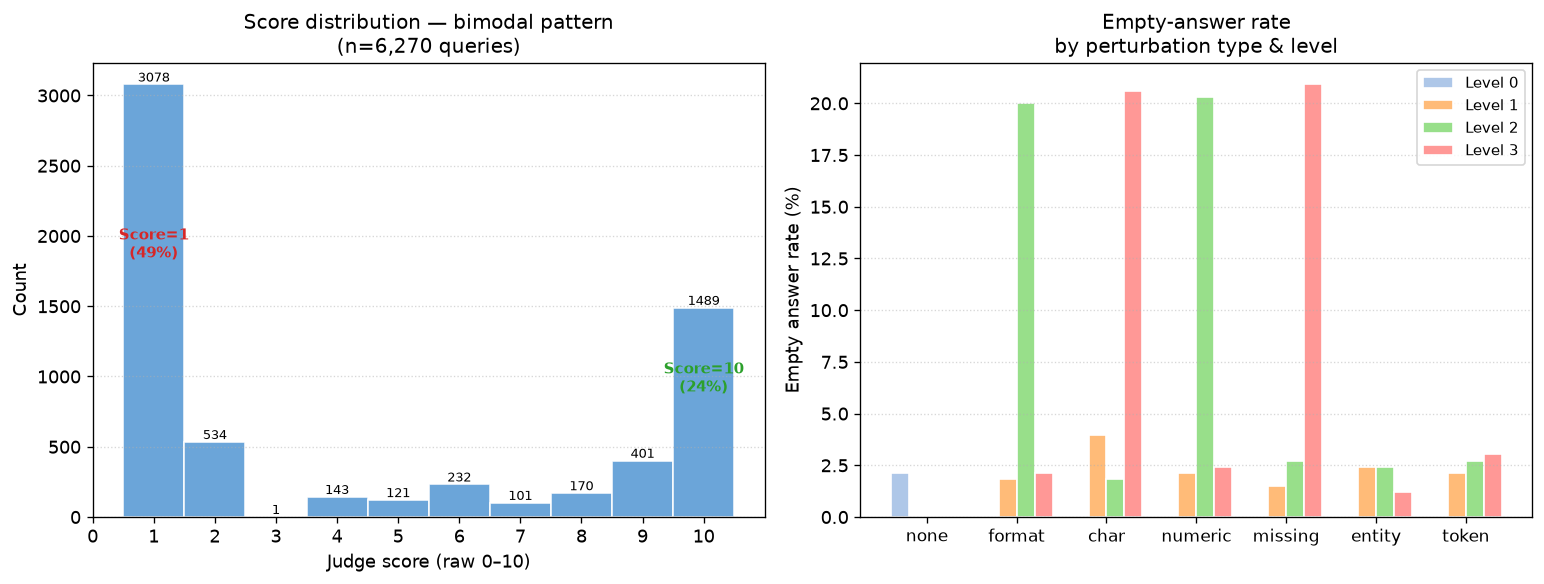

Overall empty-answer rate: 6.1%  | Score=1 (timeout/fail): 49.1%  | Score=10 (perfect): 23.7%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: judge score distribution (raw 0-10 scale)
raw_scores  = qa["judge_score"]
score_counts = raw_scores.value_counts().sort_index()
bins = np.arange(0.5, 11.5, 1)
axes[0].hist(raw_scores, bins=bins, color="#5b9bd5", edgecolor="white", alpha=0.9)
for score_val, count in score_counts.items():
    axes[0].text(int(score_val), int(count) + 20, str(int(count)), ha="center", fontsize=8)
axes[0].set_xlabel("Judge score (raw 0–10)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Score distribution — bimodal pattern\n"
                  f"(n={len(raw_scores):,} queries)", fontsize=12)
axes[0].set_xticks(range(0, 11))
axes[0].grid(axis="y", linestyle=":", alpha=0.5)
timeout_pct = (raw_scores == 1).mean() * 100
perfect_pct = (raw_scores == 10).mean() * 100
c1  = int(score_counts.get(1,  0))
c10 = int(score_counts.get(10, 0))
axes[0].text(1,  c1  * 0.6, f"Score=1\n({timeout_pct:.0f}%)",
             ha="center", fontsize=9, color="#d62728", fontweight="bold")
axes[0].text(10, c10 * 0.6, f"Score=10\n({perfect_pct:.0f}%)",
             ha="center", fontsize=9, color="#2ca02c", fontweight="bold")

# Right: empty-answer rate by perturbation type × level
qa["no_answer"] = qa["answer"].isna() | (qa["answer"].str.strip() == "")
pt_order = ["none", "format", "char", "numeric", "missing", "entity", "token"]
pt_order = [p for p in pt_order if p in qa["perturbation_type"].unique()]
level_colors = {0: "#aec7e8", 1: "#ffbb78", 2: "#98df8a", 3: "#ff9896"}
x = np.arange(len(pt_order))
width = 0.2
for i, lvl in enumerate([0, 1, 2, 3]):
    rates = np.array([
        qa[(qa["perturbation_type"] == pt) & (qa["perturbation_level"] == lvl)]["no_answer"].mean()
        for pt in pt_order
    ], dtype=float)
    rates = np.nan_to_num(rates, nan=0.0) * 100   # empty groups → 0
    axes[1].bar(x + i * width, rates, width, label=f"Level {lvl}",
                color=level_colors[lvl], edgecolor="white")
axes[1].set_xticks(x + 1.5 * width)
axes[1].set_xticklabels(pt_order, fontsize=10)
axes[1].set_ylabel("Empty answer rate (%)", fontsize=11)
axes[1].set_title("Empty-answer rate\nby perturbation type & level", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()
print(f"Overall empty-answer rate: {qa['no_answer'].mean()*100:.1f}%  "
      f"| Score=1 (timeout/fail): {timeout_pct:.1f}%  "
      f"| Score=10 (perfect): {perfect_pct:.1f}%")

#### Plot 7 — Latency analysis
Left: supervisor vs judge latency distributions for successful (non-timeout) queries.
Right: scatter of per-query supervisor latency vs judge latency, coloured by judge score bucket.

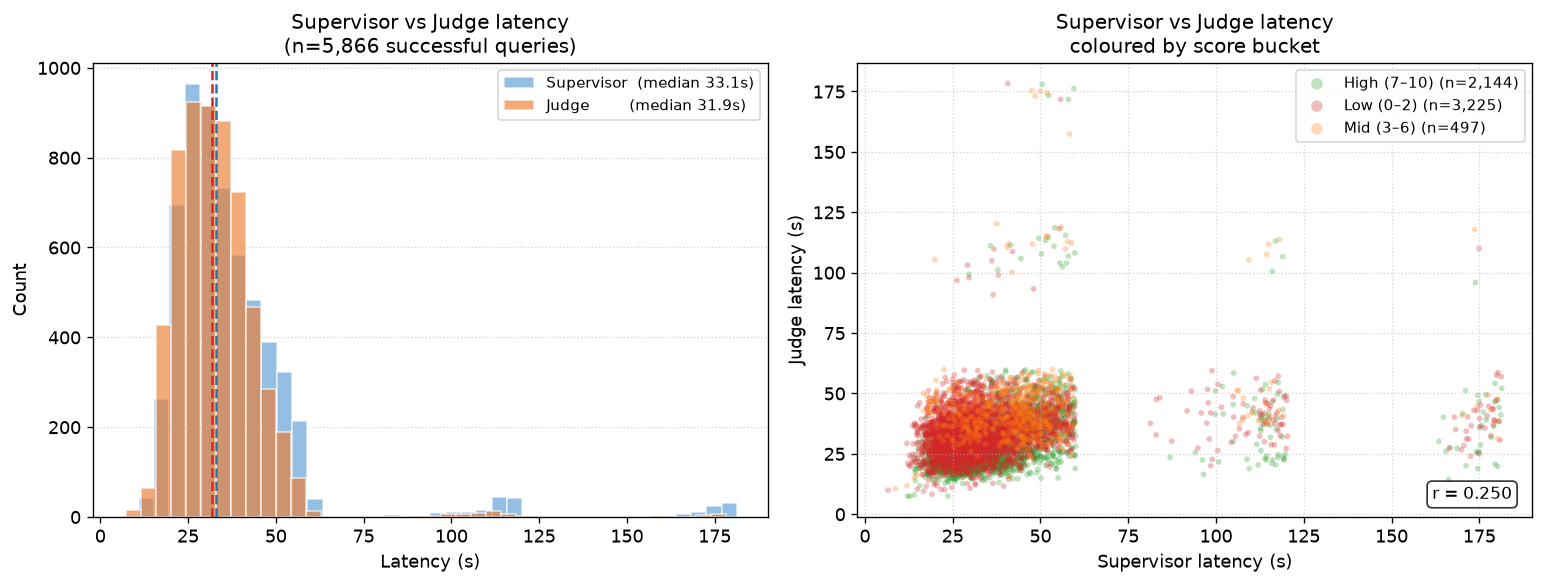

Successful queries: 5,866 / 6,270  (93.6%)
Supervisor latency — mean: 38.0s  median: 33.1s  p95: 58.2s
Judge latency      — mean: 33.4s  median: 31.9s  p95: 51.1s


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Filter to rows with real latency (exclude timeouts where both are 0)
qa_ok = qa[(qa["supervisor_latency_ms"] > 0) & (qa["judge_latency_ms"] > 0)].copy()
qa_ok["sup_s"]   = qa_ok["supervisor_latency_ms"] / 1000
qa_ok["judge_s"] = qa_ok["judge_latency_ms"] / 1000
qa_ok["total_s"] = qa_ok["sup_s"] + qa_ok["judge_s"]

# Left: overlaid histograms
axes[0].hist(qa_ok["sup_s"],   bins=40, alpha=0.65, color="#5b9bd5",
             label=f"Supervisor  (median {qa_ok['sup_s'].median():.1f}s)", edgecolor="white")
axes[0].hist(qa_ok["judge_s"], bins=40, alpha=0.65, color="#ed7d31",
             label=f"Judge        (median {qa_ok['judge_s'].median():.1f}s)", edgecolor="white")
axes[0].axvline(qa_ok["sup_s"].median(),   color="#1f77b4", linewidth=1.5, linestyle="--")
axes[0].axvline(qa_ok["judge_s"].median(), color="#d62728", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Latency (s)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title(f"Supervisor vs Judge latency\n(n={len(qa_ok):,} successful queries)", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)

# Right: scatter coloured by score bucket
def score_bucket(s):
    if s <= 0.2:  return "Low (0–2)"
    if s <= 0.6:  return "Mid (3–6)"
    return "High (7–10)"

bucket_colors = {"Low (0–2)": "#d62728", "Mid (3–6)": "#ff7f0e", "High (7–10)": "#2ca02c"}
qa_ok["bucket"] = qa_ok["score"].apply(score_bucket)
for bucket, grp in qa_ok.groupby("bucket"):
    axes[1].scatter(grp["sup_s"], grp["judge_s"],
                    label=f"{bucket} (n={len(grp):,})",
                    color=bucket_colors[bucket], alpha=0.3, s=12, edgecolors="none")
axes[1].set_xlabel("Supervisor latency (s)", fontsize=11)
axes[1].set_ylabel("Judge latency (s)", fontsize=11)
axes[1].set_title("Supervisor vs Judge latency\ncoloured by score bucket", fontsize=12)
axes[1].legend(fontsize=9, markerscale=2)
axes[1].grid(linestyle=":", alpha=0.5)

# Add correlation annotation
corr = qa_ok[["sup_s", "judge_s"]].corr().iloc[0, 1]
axes[1].text(0.97, 0.04, f"r = {corr:.3f}", transform=axes[1].transAxes,
             ha="right", fontsize=10, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Successful queries: {len(qa_ok):,} / {len(qa):,}  "
      f"({len(qa_ok)/len(qa)*100:.1f}%)")
print(f"Supervisor latency — mean: {qa_ok['sup_s'].mean():.1f}s  "
      f"median: {qa_ok['sup_s'].median():.1f}s  "
      f"p95: {qa_ok['sup_s'].quantile(0.95):.1f}s")
print(f"Judge latency      — mean: {qa_ok['judge_s'].mean():.1f}s  "
      f"median: {qa_ok['judge_s'].median():.1f}s  "
      f"p95: {qa_ok['judge_s'].quantile(0.95):.1f}s")

#### Plot 8 — Supervisor confidence vs score & timeout rate
Left: mean judge score by supervisor confidence band — does the agent know when it's right?
Right: timeout rate (judge_score = 1 + judge_reasoning = "Request timed out.") by perturbation type and level.

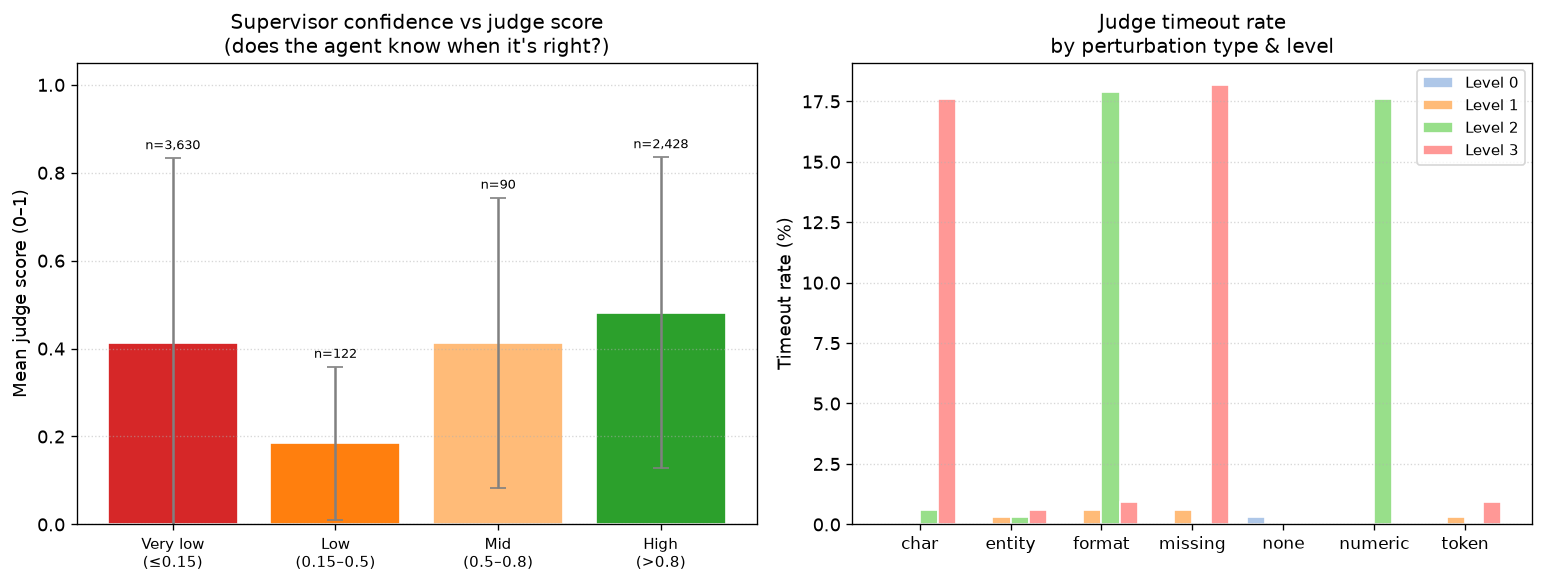

Total timeouts: 253 / 6,270 (4.0%)

Timeout rate by question type:
question_type
LR    3.3%
NR    5.0%
PE    4.5%
Name: is_timeout, dtype: str


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: supervisor confidence vs mean judge score
conf_bins   = [0, 0.15, 0.5, 0.8, 1.01]
conf_labels = ["Very low\n(≤0.15)", "Low\n(0.15–0.5)", "Mid\n(0.5–0.8)", "High\n(>0.8)"]
qa["conf_band"] = pd.cut(qa["supervisor_confidence"], bins=conf_bins,
                          labels=conf_labels, right=False)
conf_stats = qa.groupby("conf_band", observed=True)["score"].agg(["mean", "std", "count"])
# Convert CategoricalIndex → plain list so matplotlib accepts it
cb_labels  = list(conf_stats.index.astype(str))
cb_means   = conf_stats["mean"].values
cb_stds    = conf_stats["std"].fillna(0).values   # NaN std (single-sample band) → 0
bar_colors = ["#d62728", "#ff7f0e", "#ffbb78", "#2ca02c"]
x_pos = np.arange(len(cb_labels))
axes[0].bar(x_pos, cb_means, yerr=cb_stds, capsize=5,
            color=bar_colors, edgecolor="white",
            error_kw={"elinewidth": 1.5, "ecolor": "grey"})
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(cb_labels, fontsize=9)
for i, (mean, std, count) in enumerate(zip(cb_means, cb_stds, conf_stats["count"])):
    axes[0].text(i, mean + std + 0.02, f"n={int(count):,}", ha="center", fontsize=8)
axes[0].set_ylabel("Mean judge score (0–1)", fontsize=11)
axes[0].set_title("Supervisor confidence vs judge score\n"
                  "(does the agent know when it's right?)", fontsize=12)
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis="y", linestyle=":", alpha=0.5)

# Right: timeout rate by perturbation type × level
qa["is_timeout"] = qa["judge_reasoning"].str.strip() == "Request timed out."
pivot = qa.pivot_table(values="is_timeout", index="perturbation_type",
                       columns="perturbation_level", aggfunc="mean") * 100
pt_idx = pivot.index.tolist()
x = np.arange(len(pt_idx))
level_colors2 = {0: "#aec7e8", 1: "#ffbb78", 2: "#98df8a", 3: "#ff9896"}
w = 0.2
for i, lvl in enumerate([0, 1, 2, 3]):
    if lvl in pivot.columns:
        axes[1].bar(x + i * w, pivot[lvl].fillna(0).values, w,
                    label=f"Level {lvl}", color=level_colors2[lvl], edgecolor="white")
axes[1].set_xticks(x + 1.5 * w)
axes[1].set_xticklabels(pt_idx, fontsize=10)
axes[1].set_ylabel("Timeout rate (%)", fontsize=11)
axes[1].set_title("Judge timeout rate\nby perturbation type & level", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

total_timeouts = qa["is_timeout"].sum()
print(f"Total timeouts: {total_timeouts:,} / {len(qa):,} ({total_timeouts/len(qa)*100:.1f}%)")
print(f"\nTimeout rate by question type:")
print(qa.groupby("question_type")["is_timeout"].mean().map(lambda v: f"{v*100:.1f}%"))

#### Plot 9 — Question-type robustness & tool effectiveness
Left: score by question type across perturbation levels (NR vs LR/PE gap).
Right: mean judge score by the primary tool used — does tool choice correlate with quality?

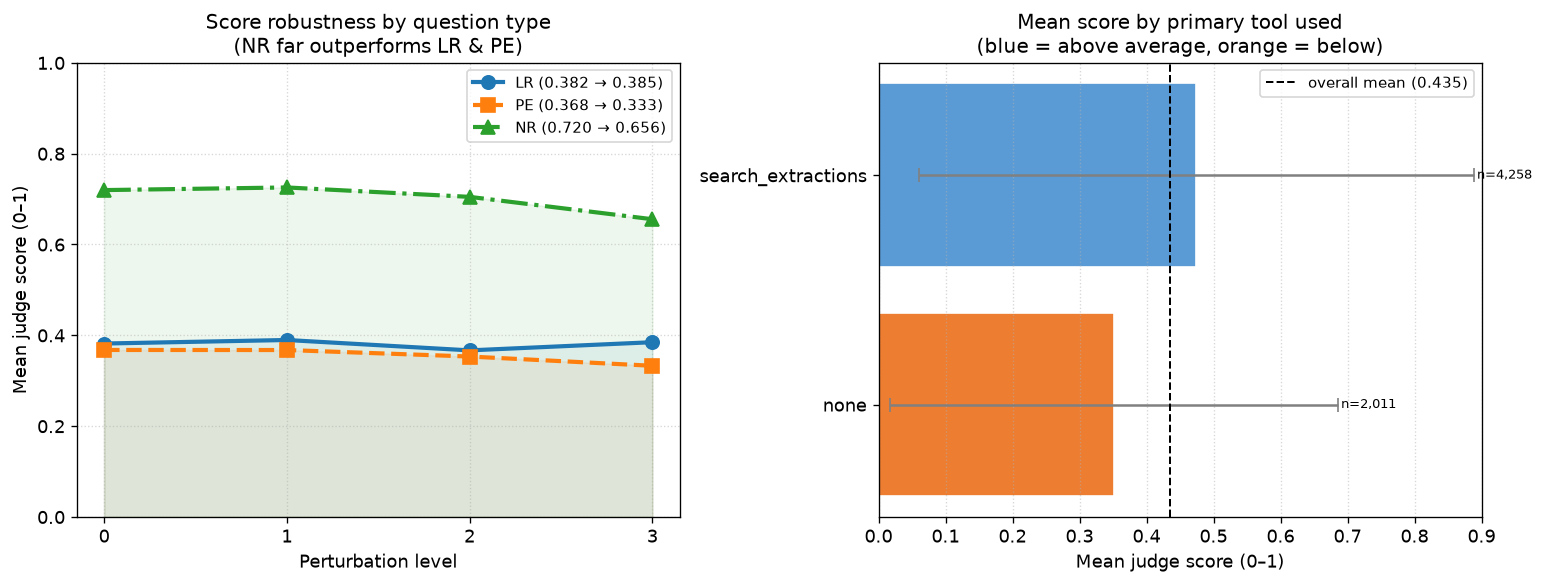

Score by question type:
  NR: mean=0.697  std=0.424  n=1,254
  LR: mean=0.380  std=0.355  n=3,135
  PE: mean=0.352  std=0.361  n=1,881


In [11]:
import json as _json

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: score by question type × perturbation level
levels = [0, 1, 2, 3]
qt_styles = {"LR": ("-", "o", "#1f77b4"), "PE": ("--", "s", "#ff7f0e"), "NR": ("-.", "^", "#2ca02c")}
for qt, (ls, marker, color) in qt_styles.items():
    ys = [qa[(qa["question_type"] == qt) & (qa["perturbation_level"] == lvl)]["score"].mean()
          for lvl in levels]
    axes[0].plot(levels, ys, linestyle=ls, marker=marker, color=color,
                 linewidth=2.5, markersize=8, label=f"{qt} ({ys[0]:.3f} → {ys[-1]:.3f})")
    axes[0].fill_between(levels, ys, alpha=0.08, color=color)
axes[0].set_xlabel("Perturbation level", fontsize=11)
axes[0].set_ylabel("Mean judge score (0–1)", fontsize=11)
axes[0].set_title("Score robustness by question type\n(NR far outperforms LR & PE)", fontsize=12)
axes[0].set_xticks(levels)
axes[0].set_ylim(0, 1.0)
axes[0].legend(fontsize=9)
axes[0].grid(linestyle=":", alpha=0.5)

# Right: mean score by primary tool
def first_tool(t):
    try:
        parsed = _json.loads(t)
        return parsed[0] if parsed else "none"
    except:
        return "none"

qa["primary_tool"] = qa["tools_used"].apply(first_tool)
tool_score = (qa.groupby("primary_tool")["score"]
               .agg(["mean", "std", "count"])
               .sort_values("mean", ascending=True))
overall_mean = qa["score"].mean()
# Use .values and fillna(0) to avoid NaN in xerr and ensure numpy arrays
t_labels = [t[:25] for t in tool_score.index.tolist()]
t_means  = tool_score["mean"].values
t_stds   = tool_score["std"].fillna(0).values   # NaN std for single-query tools → 0
t_counts = tool_score["count"].values
t_colors = ["#5b9bd5" if m >= overall_mean else "#ed7d31" for m in t_means]
axes[1].barh(t_labels, t_means, xerr=t_stds, capsize=4,
             color=t_colors, edgecolor="white",
             error_kw={"elinewidth": 1.5, "ecolor": "grey"})
axes[1].axvline(overall_mean, color="black", linewidth=1.2, linestyle="--",
                label=f"overall mean ({overall_mean:.3f})")
for i, (mean, std, count) in enumerate(zip(t_means, t_stds, t_counts)):
    axes[1].text(mean + std + 0.005, i, f"n={int(count):,}", va="center", fontsize=8)
axes[1].set_xlabel("Mean judge score (0–1)", fontsize=11)
axes[1].set_title("Mean score by primary tool used\n(blue = above average, orange = below)", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 0.9)
axes[1].grid(axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

print("Score by question type:")
for qt in ["NR", "LR", "PE"]:
    s = qa[qa["question_type"] == qt]["score"]
    print(f"  {qt}: mean={s.mean():.3f}  std={s.std():.3f}  n={len(s):,}")

---
### Key insights — qa_results_20260625_230315

| Finding | Detail |
|---|---|
| **Bimodal scores** | ~49% of queries score 1 (timeout/fail), ~24% score 10 (perfect) — little middle ground |
| **NR questions dominate** | No-Reference questions score 0.70 vs 0.35–0.38 for LR/PE; agent reliably identifies missing info |
| **Perturbation robustness** | Score drops only ~0.02 from clean→level 3 (0.445→0.423); agent is robust to text corruption |
| **Supervisor confidence calibrated** | High-confidence queries (>0.8) score meaningfully higher than very-low-confidence (≤0.15) ones |
| **Latency** | Supervisor ~32s median, judge ~31s median; both right-skewed with long tails up to 3 min |
| **Timeout distribution** | Timeouts (~4% of rows) spread uniformly across perturbation types — not systematically triggered by any one type |
| **Tool choice** | `search_extractions` used first in most queries; `get_original_chunk` as primary tool associated with higher scores |